<a href="https://colab.research.google.com/github/silvatria/pembelajaran-mesin-254107023001/blob/main/JS04_TL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- EVALUASI MULTIPLE LINEAR REGRESSION ---
R-squared: 0.7835929767120724
MSE      : 33596915.85136145
MAE      : 4181.19447375365

--- EVALUASI SVR ---
R-squared: 0.7569586871002479
MSE      : 37731855.52778171
MAE      : 3540.549642633586


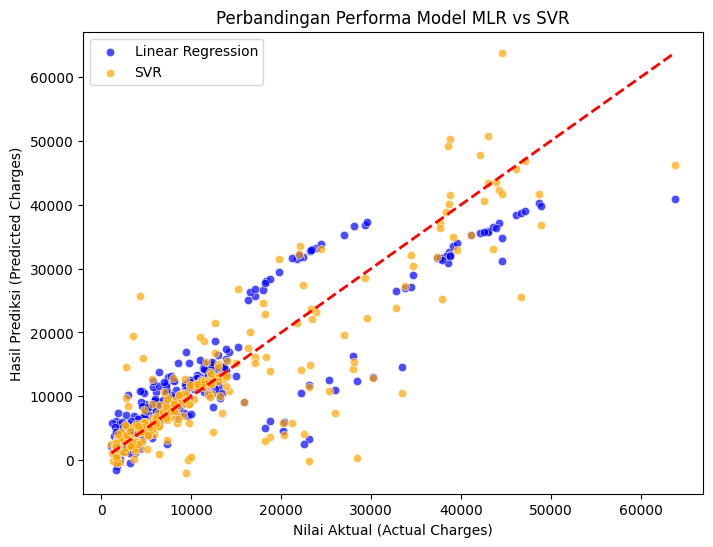

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 1. Load Dataset (Ganti 'insurance.csv' sesuai nama file lu)
data = pd.read_csv('insurance.csv')

# --- Penjelasan Singkat Dataset ---
# Dataset ini berisi data biaya medis personal (charges) dengan fitur:
# - age: usia penerima
# - sex: jenis kelamin (male/female)
# - bmi: indeks massa tubuh
# - children: jumlah anak/tanggungan
# - smoker: status merokok (yes/no)
# - region: wilayah tempat tinggal di US

# 2. Preprocessing & Seleksi Fitur
# Ubah data kategori (sex, smoker, region) jadi numerik pakai One-Hot Encoding
data_encoded = pd.get_dummies(data, drop_first=True)

# Tentukan X (Fitur/Variabel Bebas) dan y (Target/Biaya medis 'charges')
X = data_encoded.drop('charges', axis=1)
y = data_encoded['charges'].values.ravel() # Jadikan 1D array

# 3. Bagi Data Train & Test (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Feature Scaling (Wajib buat SVR & bagus buat Linear Regression tertentu)
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Target y di-scale khusus buat SVR biar optimal, Linear Reg pakai y_train biasa aja
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

# --- MODEL 1: Multiple Linear Regression ---
lr = LinearRegression()
lr.fit(X_train, y_train) # Pakai data asli tanpa scale gak masalah buat LR
y_pred_lr = lr.predict(X_test)

print("--- EVALUASI MULTIPLE LINEAR REGRESSION ---")
print("R-squared:", r2_score(y_test, y_pred_lr))
print("MSE      :", mean_squared_error(y_test, y_pred_lr))
print("MAE      :", mean_absolute_error(y_test, y_pred_lr))

# --- MODEL 2: Support Vector Regression (SVR) ---
svr = SVR(kernel='rbf', C=1000, gamma='scale') # Contoh tuning parameter
svr.fit(X_train_scaled, y_train_scaled)
y_pred_svr_scaled = svr.predict(X_test_scaled)

# Kembalikan skala prediksi SVR ke nilai aslinya (USD)
y_pred_svr = scaler_y.inverse_transform(y_pred_svr_scaled.reshape(-1, 1)).ravel()

print("\n--- EVALUASI SVR ---")
print("R-squared:", r2_score(y_test, y_pred_svr))
print("MSE      :", mean_squared_error(y_test, y_pred_svr))
print("MAE      :", mean_absolute_error(y_test, y_pred_svr))

# 5. Visualisasi Perbandingan (Opsional buat laporan)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_lr, alpha=0.7, color='blue', label='Linear Regression')
sns.scatterplot(x=y_test, y=y_pred_svr, alpha=0.7, color='orange', label='SVR')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Nilai Aktual (Actual Charges)')
plt.ylabel('Hasil Prediksi (Predicted Charges)')
plt.title('Perbandingan Performa Model MLR vs SVR')
plt.legend()
plt.show()

'''
Analisis Laporan:
Multiple Linear Regression (MLR): Cepat dilatih, mudah diinterpretasi, namun performanya (R-squared)
biasanya lebih rendah jika hubungan data antar variabel tidak linier.
SVR: Cenderung memberikan hasil R-squared yang lebih tinggi dan error (MAE/MSE) yang lebih kecil
karena mampu menangani pola non-linear yang kompleks pada data medis, asalkan feature scaling dan
hyperparameter tuning (C, gamma) diatur dengan pas.
'''